# SAR Sampling Backend Profiling

This notebook profiles a fixed SAR model across PyMC sampling backends on a moderate spatial benchmark.

The comparison keeps the SAR specification and log-determinant method fixed and varies the sampling backend only.

Dataset setup:
- a 20 x 20 rook-contiguity grid with 400 spatial units
- one intercept and two continuous regressors
- a SAR data-generating process simulated from the shared `bayespecon.dgp` module

Backends compared:
- `c`: PyMC NUTS with the default C-backed `FAST_RUN` compilation mode
- `numba`: PyMC NUTS with `NUMBA` compilation mode
- `numpyro`: JAX-backed NUTS via NumPyro
- `blackjax`: JAX-backed NUTS via BlackJAX

The notebook records runtime, posterior means, and divergence counts. Backends that are unavailable in the current environment are skipped automatically.

In [13]:
import importlib.util
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

from bayespecon import dgp
from bayespecon.logdet import make_logdet_fn

In [14]:
PROFILE_CFG = {
    'grid_rows': 20,
    'grid_cols': 20,
    'draws': 250,
    'tune': 250,
    'chains': 4,
    'cores': 2,
    'seed': 2026,
    'logdet_method': 'eigenvalue',
}

BACKENDS = {
    'c': {
        'nuts_sampler': 'pymc',
        'compile_kwargs': {'mode': 'FAST_RUN'},
        'requires': [],
    },
    'numba': {
        'nuts_sampler': 'pymc',
        'compile_kwargs': {'mode': 'NUMBA'},
        'requires': ['numba'],
    },
    'numpyro': {
        'nuts_sampler': 'numpyro',
        'compile_kwargs': None,
        'requires': ['numpyro'],
    },
    'blackjax': {
        'nuts_sampler': 'blackjax',
        'compile_kwargs': None,
        'requires': ['blackjax'],
    },
}

TRUE_BETA = np.array([1.0, 0.8, -0.5], dtype=np.float64)
TRUE_RHO = 0.35
TRUE_SIGMA = 0.7

In [15]:
def make_rook_w(n_rows: int, n_cols: int) -> np.ndarray:
    """Create a row-standardized rook-contiguity grid weights matrix."""
    n = n_rows * n_cols
    W = np.zeros((n, n), dtype=np.float64)
    for r in range(n_rows):
        for c in range(n_cols):
            i = r * n_cols + c
            if r > 0:
                W[i, (r - 1) * n_cols + c] = 1.0
            if r < n_rows - 1:
                W[i, (r + 1) * n_cols + c] = 1.0
            if c > 0:
                W[i, r * n_cols + (c - 1)] = 1.0
            if c < n_cols - 1:
                W[i, r * n_cols + (c + 1)] = 1.0
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    return W / row_sums


def backend_available(requirements: list[str]) -> bool:
    return all(importlib.util.find_spec(name) is not None for name in requirements)


def simulate_sar_data(n_rows: int, n_cols: int, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    W = make_rook_w(n_rows, n_cols)
    sim = dgp.simulate_sar(
        W=W,
        rho=TRUE_RHO,
        beta=TRUE_BETA,
        sigma=TRUE_SIGMA,
        rng=rng,
    )
    return sim['y'], sim['X'], sim['W_dense']


def build_sar_model(y: np.ndarray, X: np.ndarray, W: np.ndarray, logdet_method: str = 'eigenvalue') -> pm.Model:
    with pm.Model() as model:
        rho = pm.Uniform('rho', lower=-0.95, upper=0.95)
        beta = pm.Normal('beta', mu=0.0, sigma=2.0, shape=X.shape[1])
        sigma = pm.HalfNormal('sigma', sigma=1.0)

        mu = rho * (W @ y) + pt.dot(X, beta)
        pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
        pm.Potential(
            'jacobian',
            make_logdet_fn(W, method=logdet_method, rho_min=-0.95, rho_max=0.95)(rho),
        )

    return model


def fit_backend(backend_name: str, y: np.ndarray, X: np.ndarray, W: np.ndarray) -> dict:
    cfg = BACKENDS[backend_name]
    if not backend_available(cfg['requires']):
        return {
            'backend': backend_name,
            'available': False,
            'total_time_s': np.nan,
            'rho_hat': np.nan,
            'beta_0_hat': np.nan,
            'beta_1_hat': np.nan,
            'beta_2_hat': np.nan,
            'divergences': np.nan,
            'error': 'missing optional dependency',
        }

    t0 = time.perf_counter()
    try:
        model = build_sar_model(y, X, W, logdet_method=PROFILE_CFG['logdet_method'])
        with model:
            idata = pm.sample(
                draws=PROFILE_CFG['draws'],
                tune=PROFILE_CFG['tune'],
                chains=PROFILE_CFG['chains'],
                cores=PROFILE_CFG['cores'],
                random_seed=PROFILE_CFG['seed'],
                progressbar=False,
                compute_convergence_checks=False,
                nuts_sampler=cfg['nuts_sampler'],
                compile_kwargs=cfg['compile_kwargs'],
            )
        elapsed_s = time.perf_counter() - t0

        beta_hat = idata.posterior['beta'].mean(('chain', 'draw')).to_numpy()
        rho_hat = float(idata.posterior['rho'].mean(('chain', 'draw')).to_numpy())
        divergences = int(idata.sample_stats['diverging'].sum().to_numpy())

        return {
            'backend': backend_name,
            'available': True,
            'total_time_s': elapsed_s,
            'rho_hat': rho_hat,
            'beta_0_hat': float(beta_hat[0]),
            'beta_1_hat': float(beta_hat[1]),
            'beta_2_hat': float(beta_hat[2]),
            'divergences': divergences,
            'error': '',
        }
    except Exception as exc:
        return {
            'backend': backend_name,
            'available': True,
            'total_time_s': np.nan,
            'rho_hat': np.nan,
            'beta_0_hat': np.nan,
            'beta_1_hat': np.nan,
            'beta_2_hat': np.nan,
            'divergences': np.nan,
            'error': f'{type(exc).__name__}: {exc}',
        }

In [16]:
y, X, W = simulate_sar_data(
    n_rows=PROFILE_CFG['grid_rows'],
    n_cols=PROFILE_CFG['grid_cols'],
    seed=PROFILE_CFG['seed'],
)

rows = []
for backend_name in BACKENDS:
    print(f'Profiling backend={backend_name}...')
    rows.append(fit_backend(backend_name, y, X, W))

results = pd.DataFrame(rows)
results['rho_abs_error'] = (results['rho_hat'] - TRUE_RHO).abs()
results['beta_rmse'] = np.sqrt(
    ((results[['beta_0_hat', 'beta_1_hat', 'beta_2_hat']].to_numpy() - TRUE_BETA[None, :]) ** 2).mean(axis=1)
)
results = results.sort_values(['available', 'total_time_s'], ascending=[False, True], na_position='last').reset_index(drop=True)
results

Initializing NUTS using jitter+adapt_diag...


Profiling backend=c...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...


Profiling backend=numba...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


Profiling backend=numpyro...
Profiling backend=blackjax...


,backend,available,total_time_s,rho_hat,beta_0_hat,beta_1_hat,beta_2_hat,divergences,error,rho_abs_error,beta_rmse
0,numba,True,0.757523,0.362441,0.924601,0.793588,-0.498303,0,,0.012441,0.043700
1,c,True,0.824224,0.363278,0.924193,0.790805,-0.497743,0,,0.013278,0.044107
2,numpyro,True,1.157998,0.363504,0.921581,0.789732,-0.497780,0,,0.013504,0.045680
3,blackjax,True,1.349854,0.360554,0.927291,0.792438,-0.495486,0,,0.010554,0.042285


In [17]:
display_cols = [
    'backend',
    'available',
    'total_time_s',
    'rho_hat',
    'rho_abs_error',
    'beta_rmse',
    'divergences',
    'error',
]
display(results[display_cols].round({'total_time_s': 3, 'rho_hat': 3, 'rho_abs_error': 3, 'beta_rmse': 3}))

,backend,available,total_time_s,rho_hat,rho_abs_error,beta_rmse,divergences,error
0,numba,True,0.758,0.362,0.012,0.044,0,
1,c,True,0.824,0.363,0.013,0.044,0,
2,numpyro,True,1.158,0.364,0.014,0.046,0,
3,blackjax,True,1.350,0.361,0.011,0.042,0,


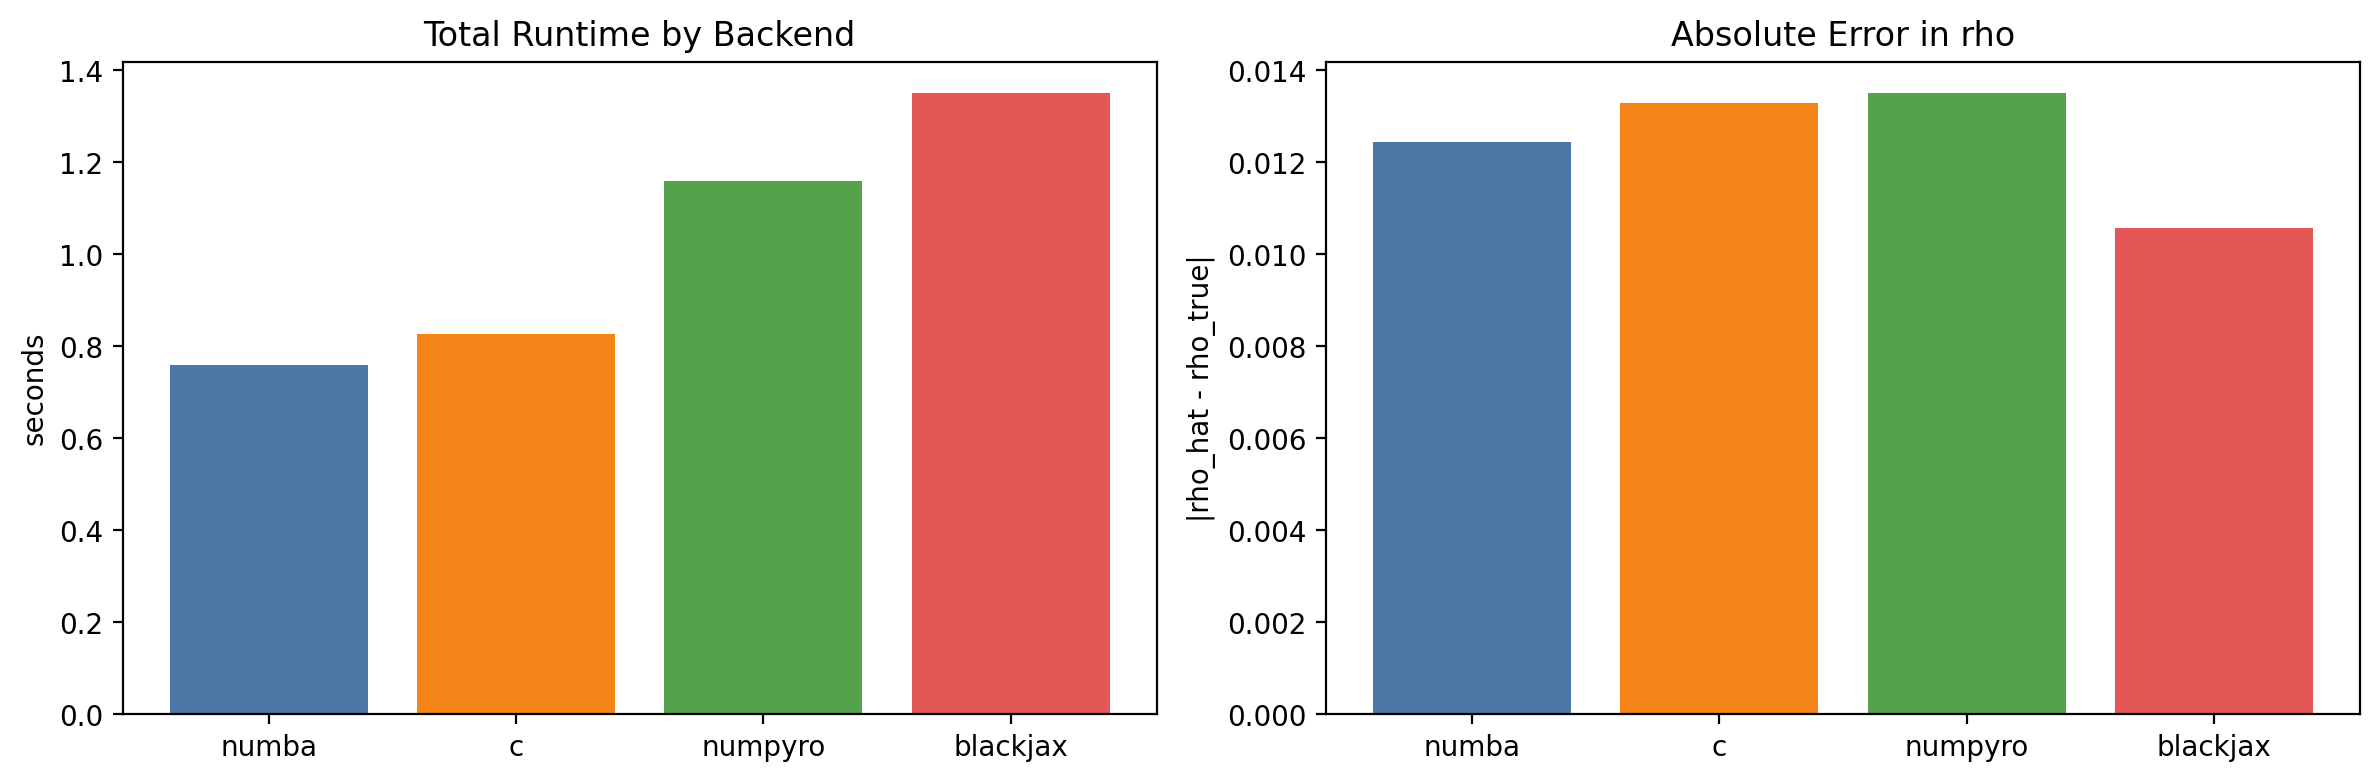

In [18]:
ok = results[results['total_time_s'].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not ok.empty:
    axes[0].bar(ok['backend'], ok['total_time_s'], color=['#4c78a8', '#f58518', '#54a24b', '#e45756'][: len(ok)])
    axes[0].set_title('Total Runtime by Backend')
    axes[0].set_ylabel('seconds')

    axes[1].bar(ok['backend'], ok['rho_abs_error'], color=['#4c78a8', '#f58518', '#54a24b', '#e45756'][: len(ok)])
    axes[1].set_title('Absolute Error in rho')
    axes[1].set_ylabel('|rho_hat - rho_true|')
else:
    axes[0].text(0.5, 0.5, 'No successful backend runs', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No successful backend runs', ha='center', va='center')
    axes[0].set_axis_off()
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
# Second Example: 1,500 Observations (30 x 50 Grid)
# This second benchmark uses a larger rectangular rook-contiguity grid
# with exactly 1,500 observations.

In [20]:
y_1500, X_1500, W_1500 = simulate_sar_data(n_rows=30, n_cols=50, seed=PROFILE_CFG['seed'])

rows_1500 = []
for backend_name in BACKENDS:
    print(f'Profiling backend={backend_name} on n=1500...')
    rows_1500.append(fit_backend(backend_name, y_1500, X_1500, W_1500))

results_1500 = pd.DataFrame(rows_1500)
results_1500['rho_abs_error'] = (results_1500['rho_hat'] - TRUE_RHO).abs()
results_1500['beta_rmse'] = np.sqrt(
    ((results_1500[['beta_0_hat', 'beta_1_hat', 'beta_2_hat']].to_numpy() - TRUE_BETA[None, :]) ** 2).mean(axis=1)
)
results_1500 = results_1500.sort_values(['available', 'total_time_s'], ascending=[False, True], na_position='last').reset_index(drop=True)

display(results_1500[display_cols].round({'total_time_s': 3, 'rho_hat': 3, 'rho_abs_error': 3, 'beta_rmse': 3}))

Profiling backend=c on n=1500...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 1 seconds.


Profiling backend=numba on n=1500...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


Profiling backend=numpyro on n=1500...
Profiling backend=blackjax on n=1500...


,backend,available,total_time_s,rho_hat,rho_abs_error,beta_rmse,divergences,error
0,blackjax,True,1.576,0.369,0.019,0.013,0,
1,numba,True,1.676,0.369,0.019,0.013,0,
2,numpyro,True,1.774,0.370,0.020,0.014,0,
3,c,True,2.065,0.371,0.021,0.016,0,


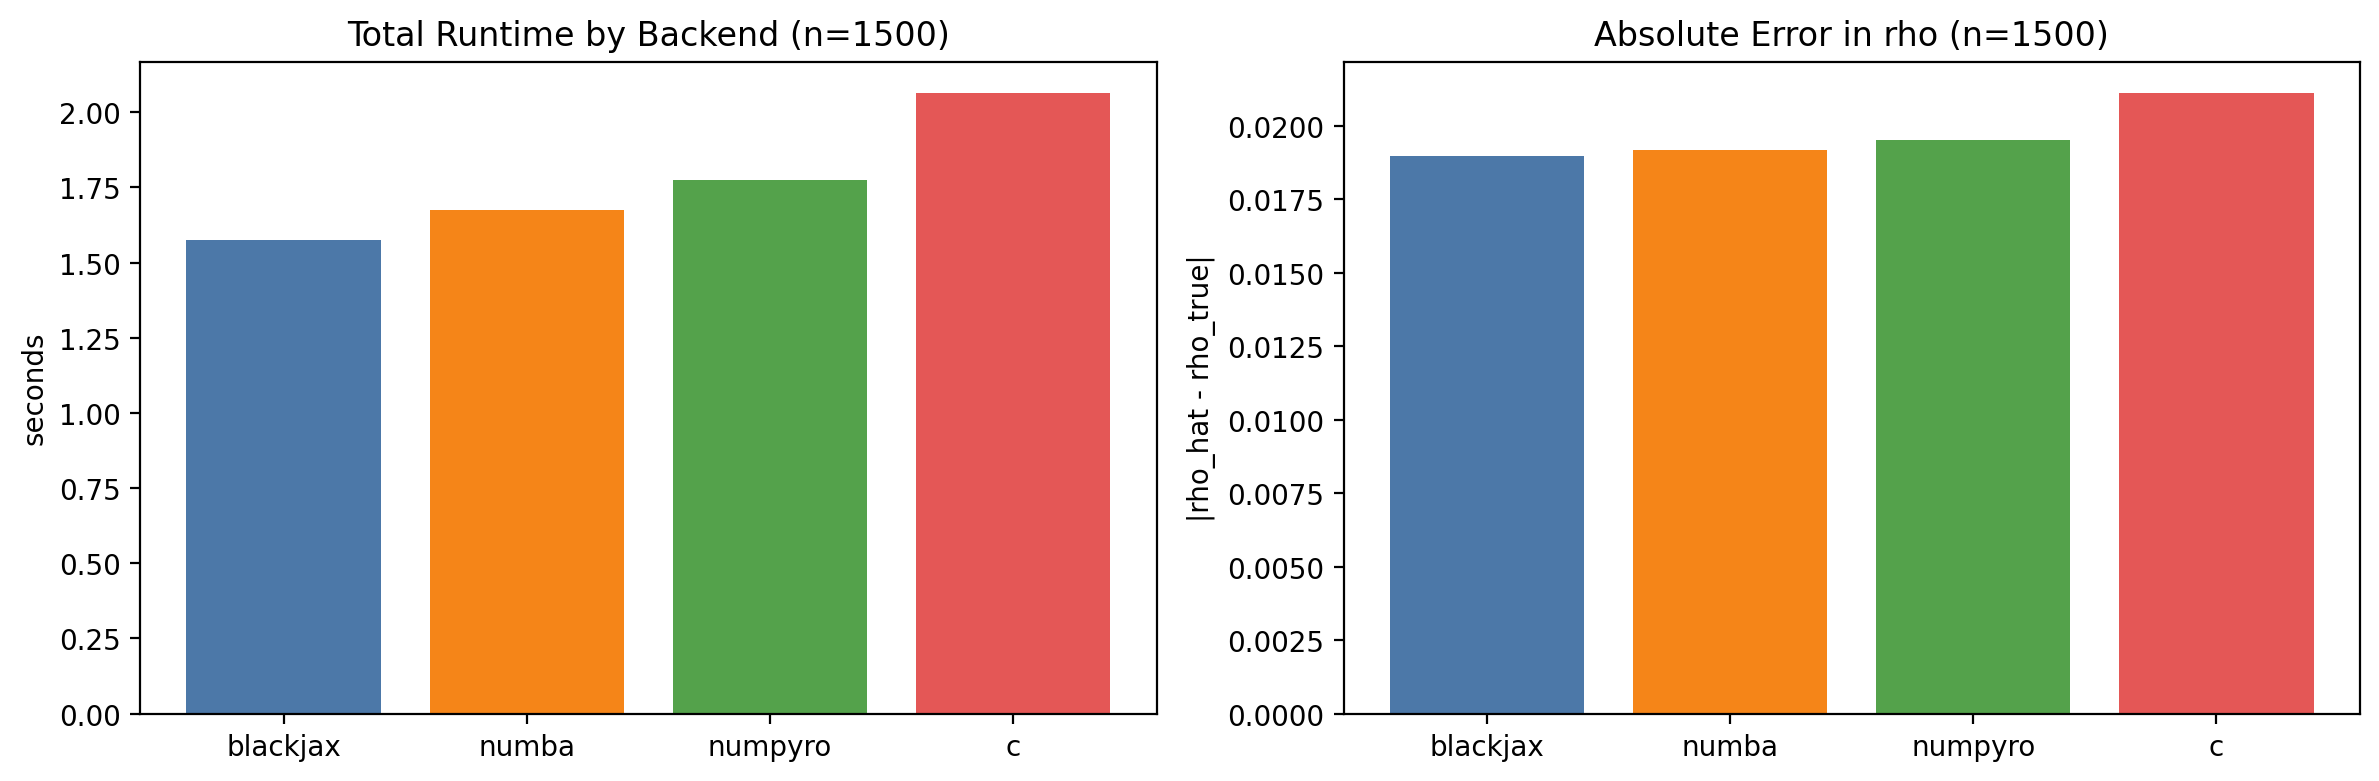

In [21]:
ok_1500 = results_1500[results_1500['total_time_s'].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not ok_1500.empty:
    axes[0].bar(
        ok_1500['backend'],
        ok_1500['total_time_s'],
        color=['#4c78a8', '#f58518', '#54a24b', '#e45756'][: len(ok_1500)],
    )
    axes[0].set_title('Total Runtime by Backend (n=1500)')
    axes[0].set_ylabel('seconds')

    axes[1].bar(
        ok_1500['backend'],
        ok_1500['rho_abs_error'],
        color=['#4c78a8', '#f58518', '#54a24b', '#e45756'][: len(ok_1500)],
    )
    axes[1].set_title('Absolute Error in rho (n=1500)')
    axes[1].set_ylabel('|rho_hat - rho_true|')
else:
    axes[0].text(0.5, 0.5, 'No successful backend runs', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No successful backend runs', ha='center', va='center')
    axes[0].set_axis_off()
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### Plot For The 1,500-Observation Example

The chart below summarizes runtime and rho error for the larger benchmark.

## Reading The Results

Interpret the tables and plots with two constraints in mind:

- these settings are still benchmark-sized, even though the spatial graph is much more realistic than a 1D lattice
- JAX-backed samplers often pay an upfront compilation cost that can dominate shorter runs

For heavier benchmarks, increase `grid_rows`, `grid_cols`, `draws`, and `tune` in `PROFILE_CFG`, or add more large-grid examples like the 1,500-observation case.